# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [8]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  17.2M      0 --:--:--  0:00:50 --:--:-- 39.3M


In [9]:
!rm SUSY.csv

rm: cannot remove 'SUSY.csv': No such file or directory


In [13]:
!gunzip SUSY.csv.gz

gzip: SUSY.csv.gz: No such file or directory


In [14]:
ls -lh

total 2.3G
-rw-r--r-- 1 kabir kabir 390K Mar 26 17:16 Lab.7.ipynb
-rw-r--r-- 1 kabir kabir 5.9M Mar 19 22:25 Lab.7.pdf
-rw-r--r-- 1 kabir kabir 2.3G Mar 26 17:12 SUSY.csv


The data is provided as a comma separated file.

In [15]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [16]:
!ls -lh

total 2.3G
-rw-r--r-- 1 kabir kabir 389K Mar 26 17:18 Lab.7.ipynb
-rw-r--r-- 1 kabir kabir 5.9M Mar 19 22:25 Lab.7.pdf
-rw-r--r-- 1 kabir kabir 2.3G Mar 26 17:12 SUSY.csv


We see that we have 5 million datapoints.

In [17]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [18]:
!head -500000 SUSY.csv > SUSY-small.csv

In [19]:
ls -lh

total 2.5G
-rw-r--r-- 1 kabir kabir 389K Mar 26 17:18 Lab.7.ipynb
-rw-r--r-- 1 kabir kabir 5.9M Mar 19 22:25 Lab.7.pdf
-rw-r--r-- 1 kabir kabir 228M Mar 26 17:35 SUSY-small.csv
-rw-r--r-- 1 kabir kabir 2.3G Mar 26 17:12 SUSY.csv


In [20]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [21]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [22]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [23]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [24]:
FeatureNames

['MT2',
 'MET_rel',
 'S_R',
 'dPhi_r_b',
 'M_Delta_R',
 'M_R',
 'R',
 'M_TR_2',
 'cos_theta_r1',
 'axial_MET']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [26]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [27]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [28]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


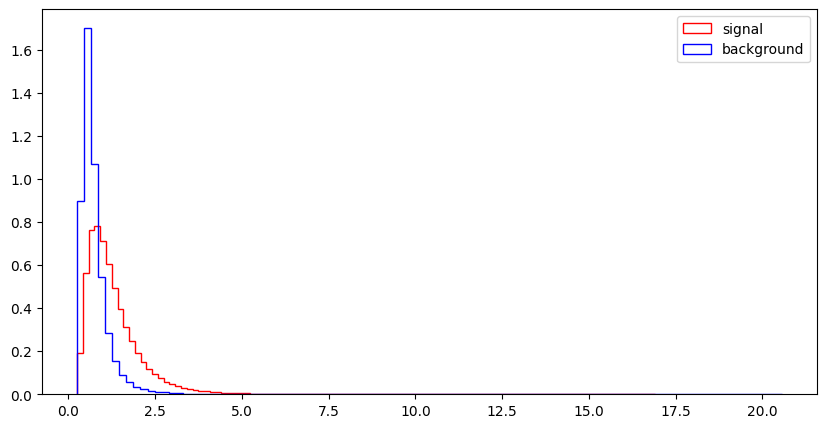

l_1_eta


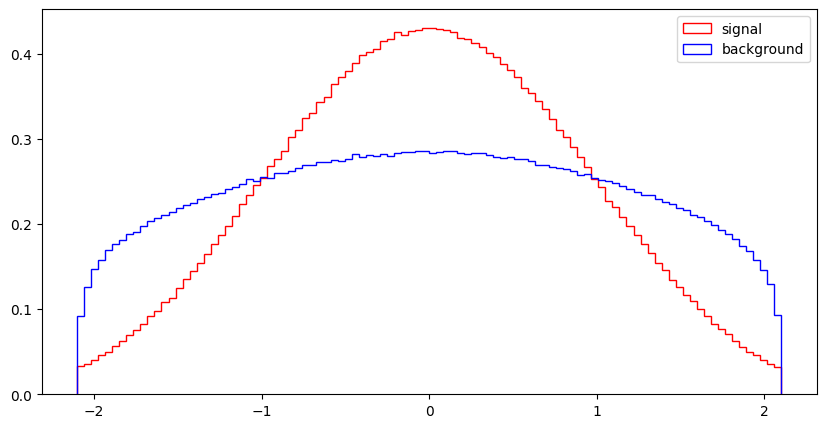

l_1_phi


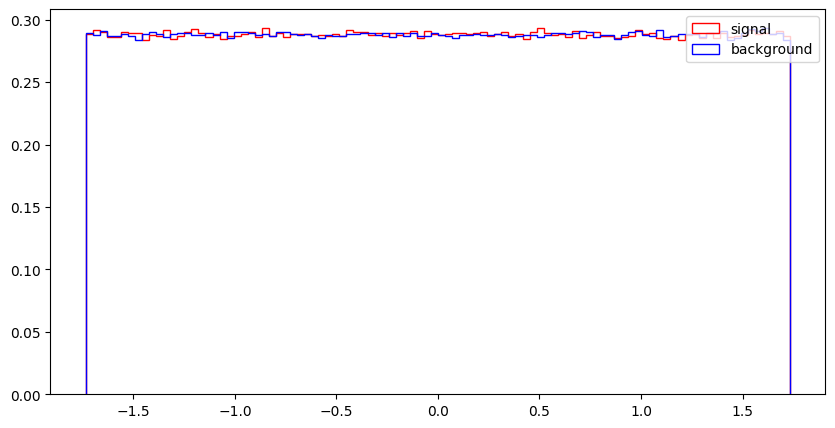

l_2_pT


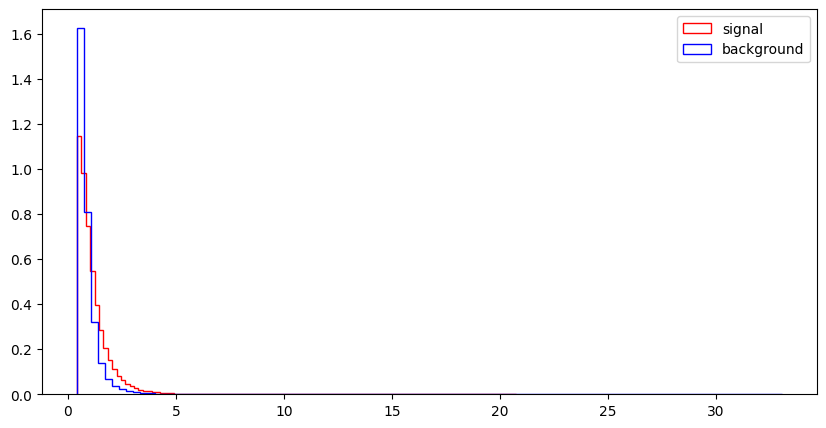

l_2_eta


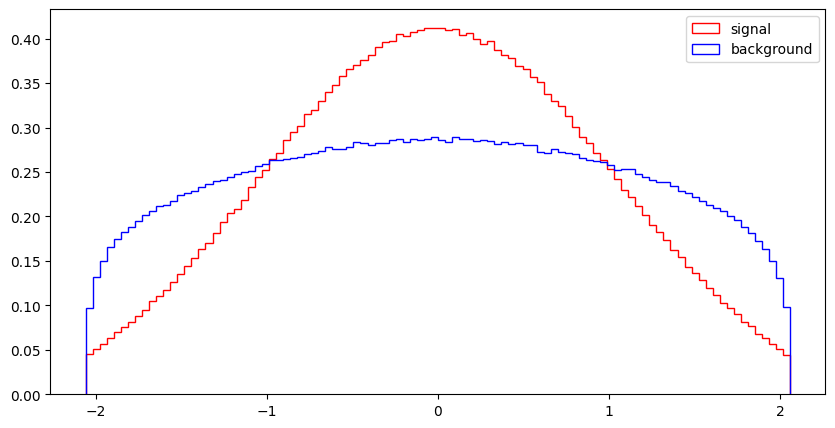

l_2_phi


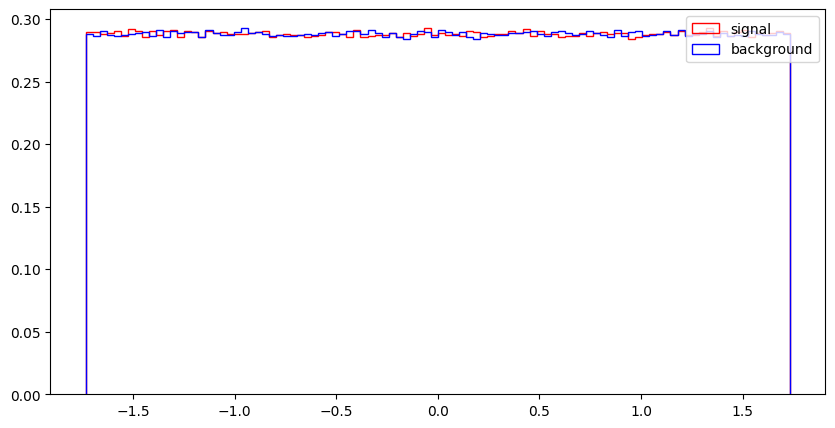

MET


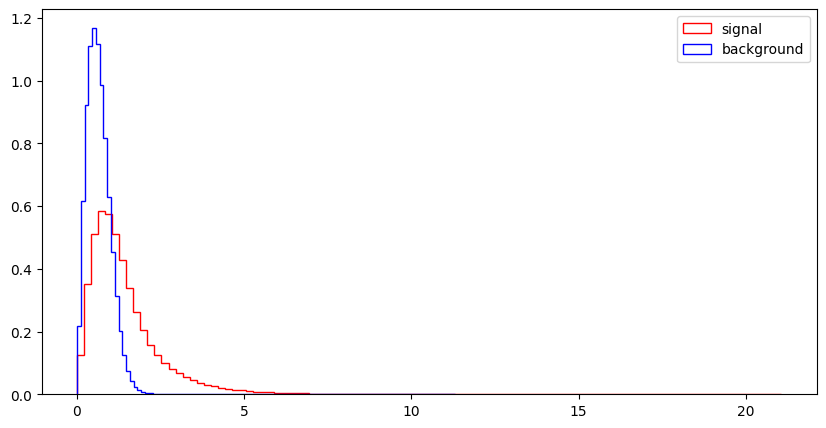

MET_phi


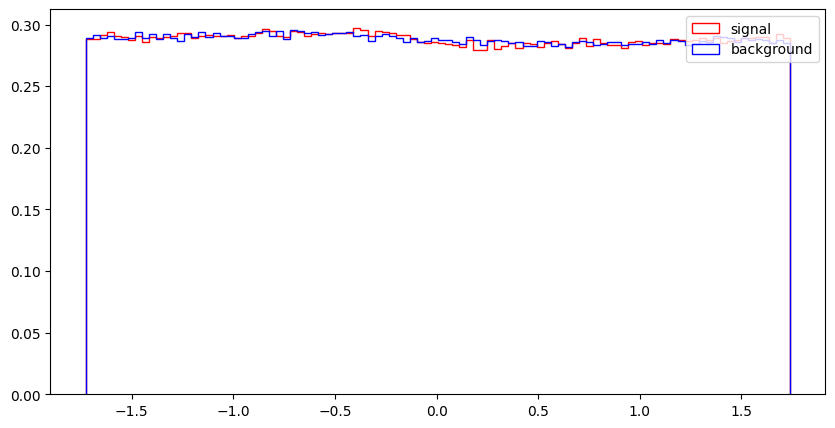

MET_rel


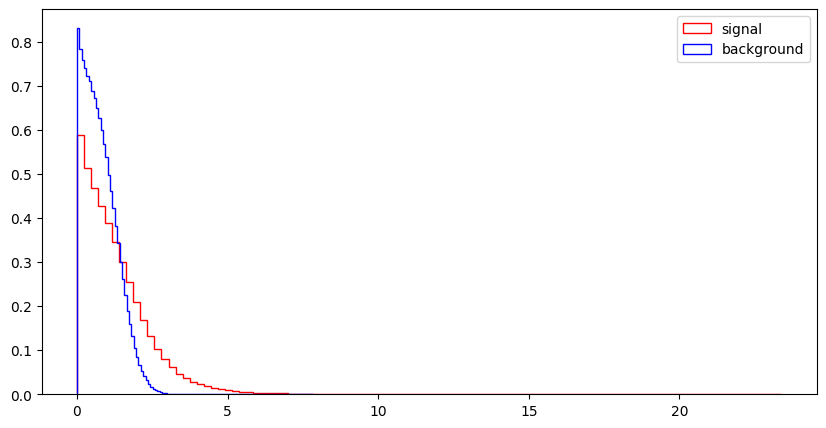

axial_MET


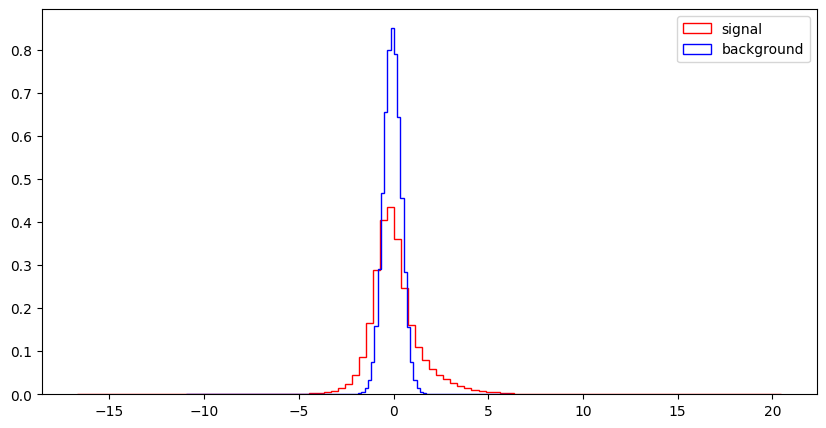

M_R


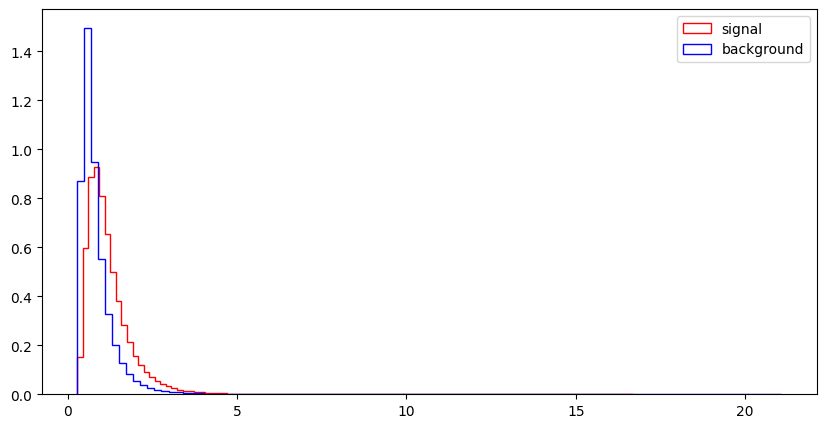

M_TR_2


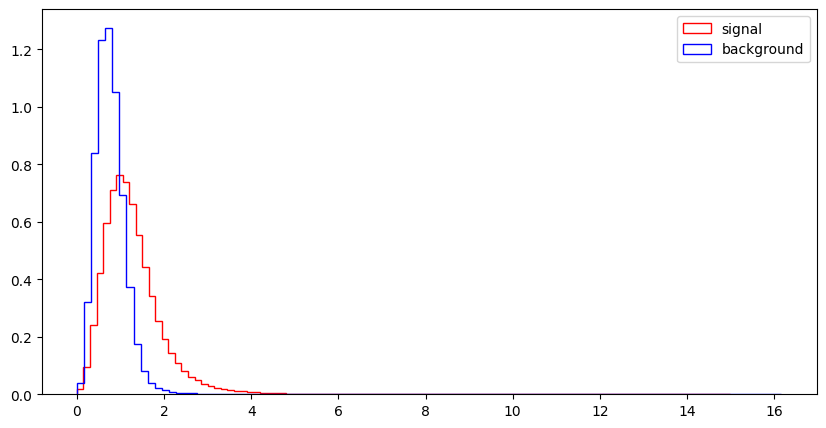

R


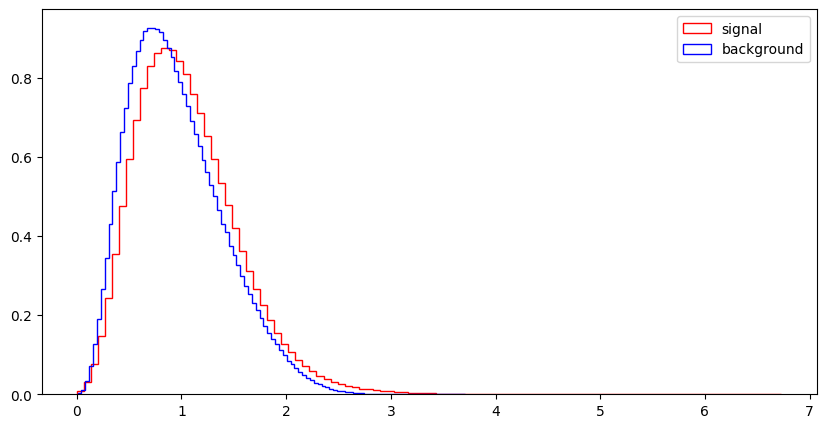

MT2


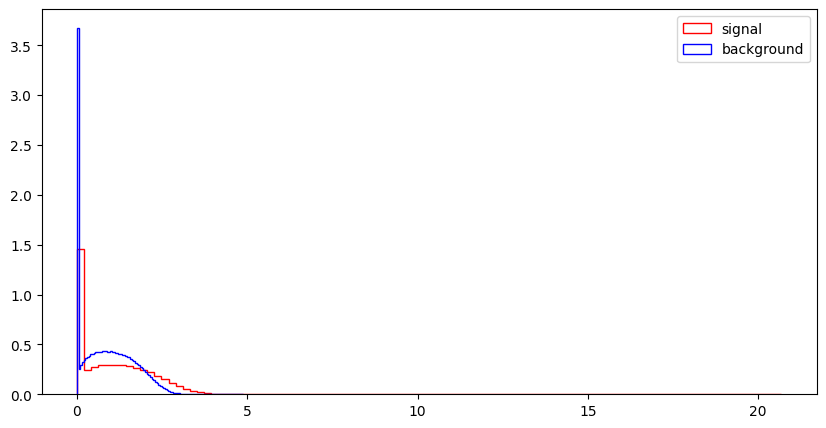

S_R


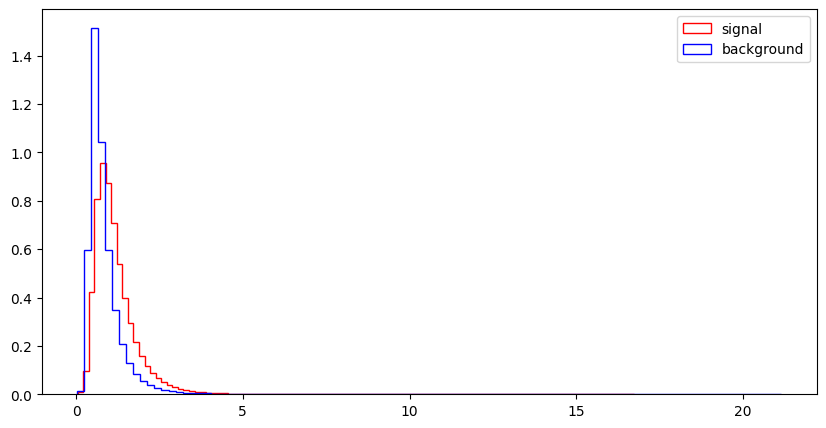

M_Delta_R


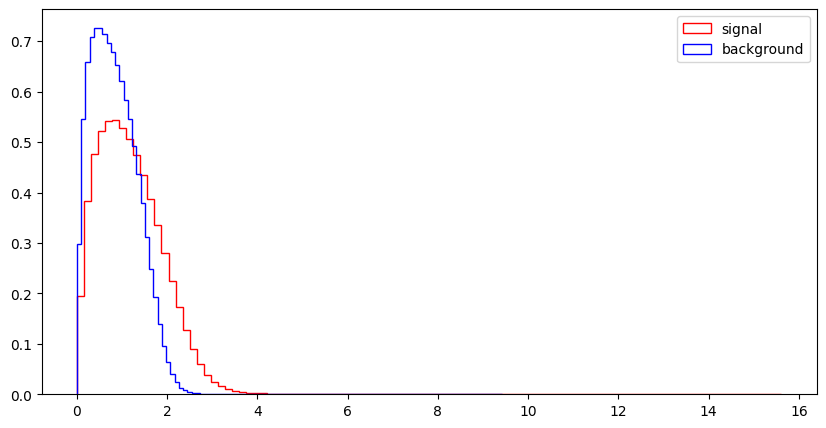

dPhi_r_b


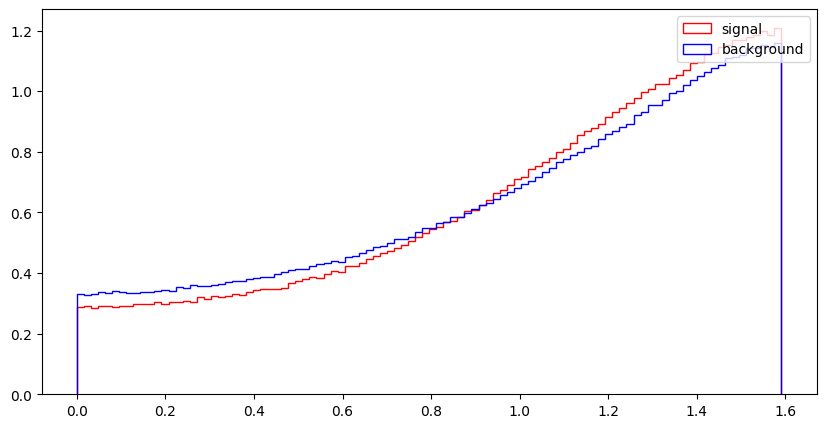

cos_theta_r1


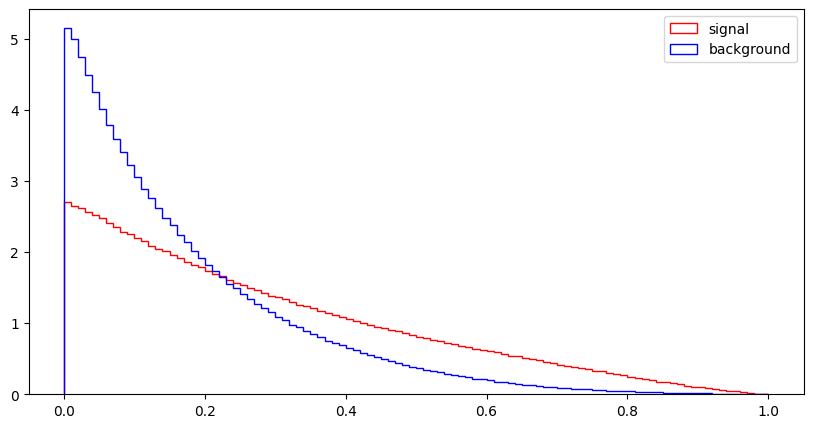

In [29]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

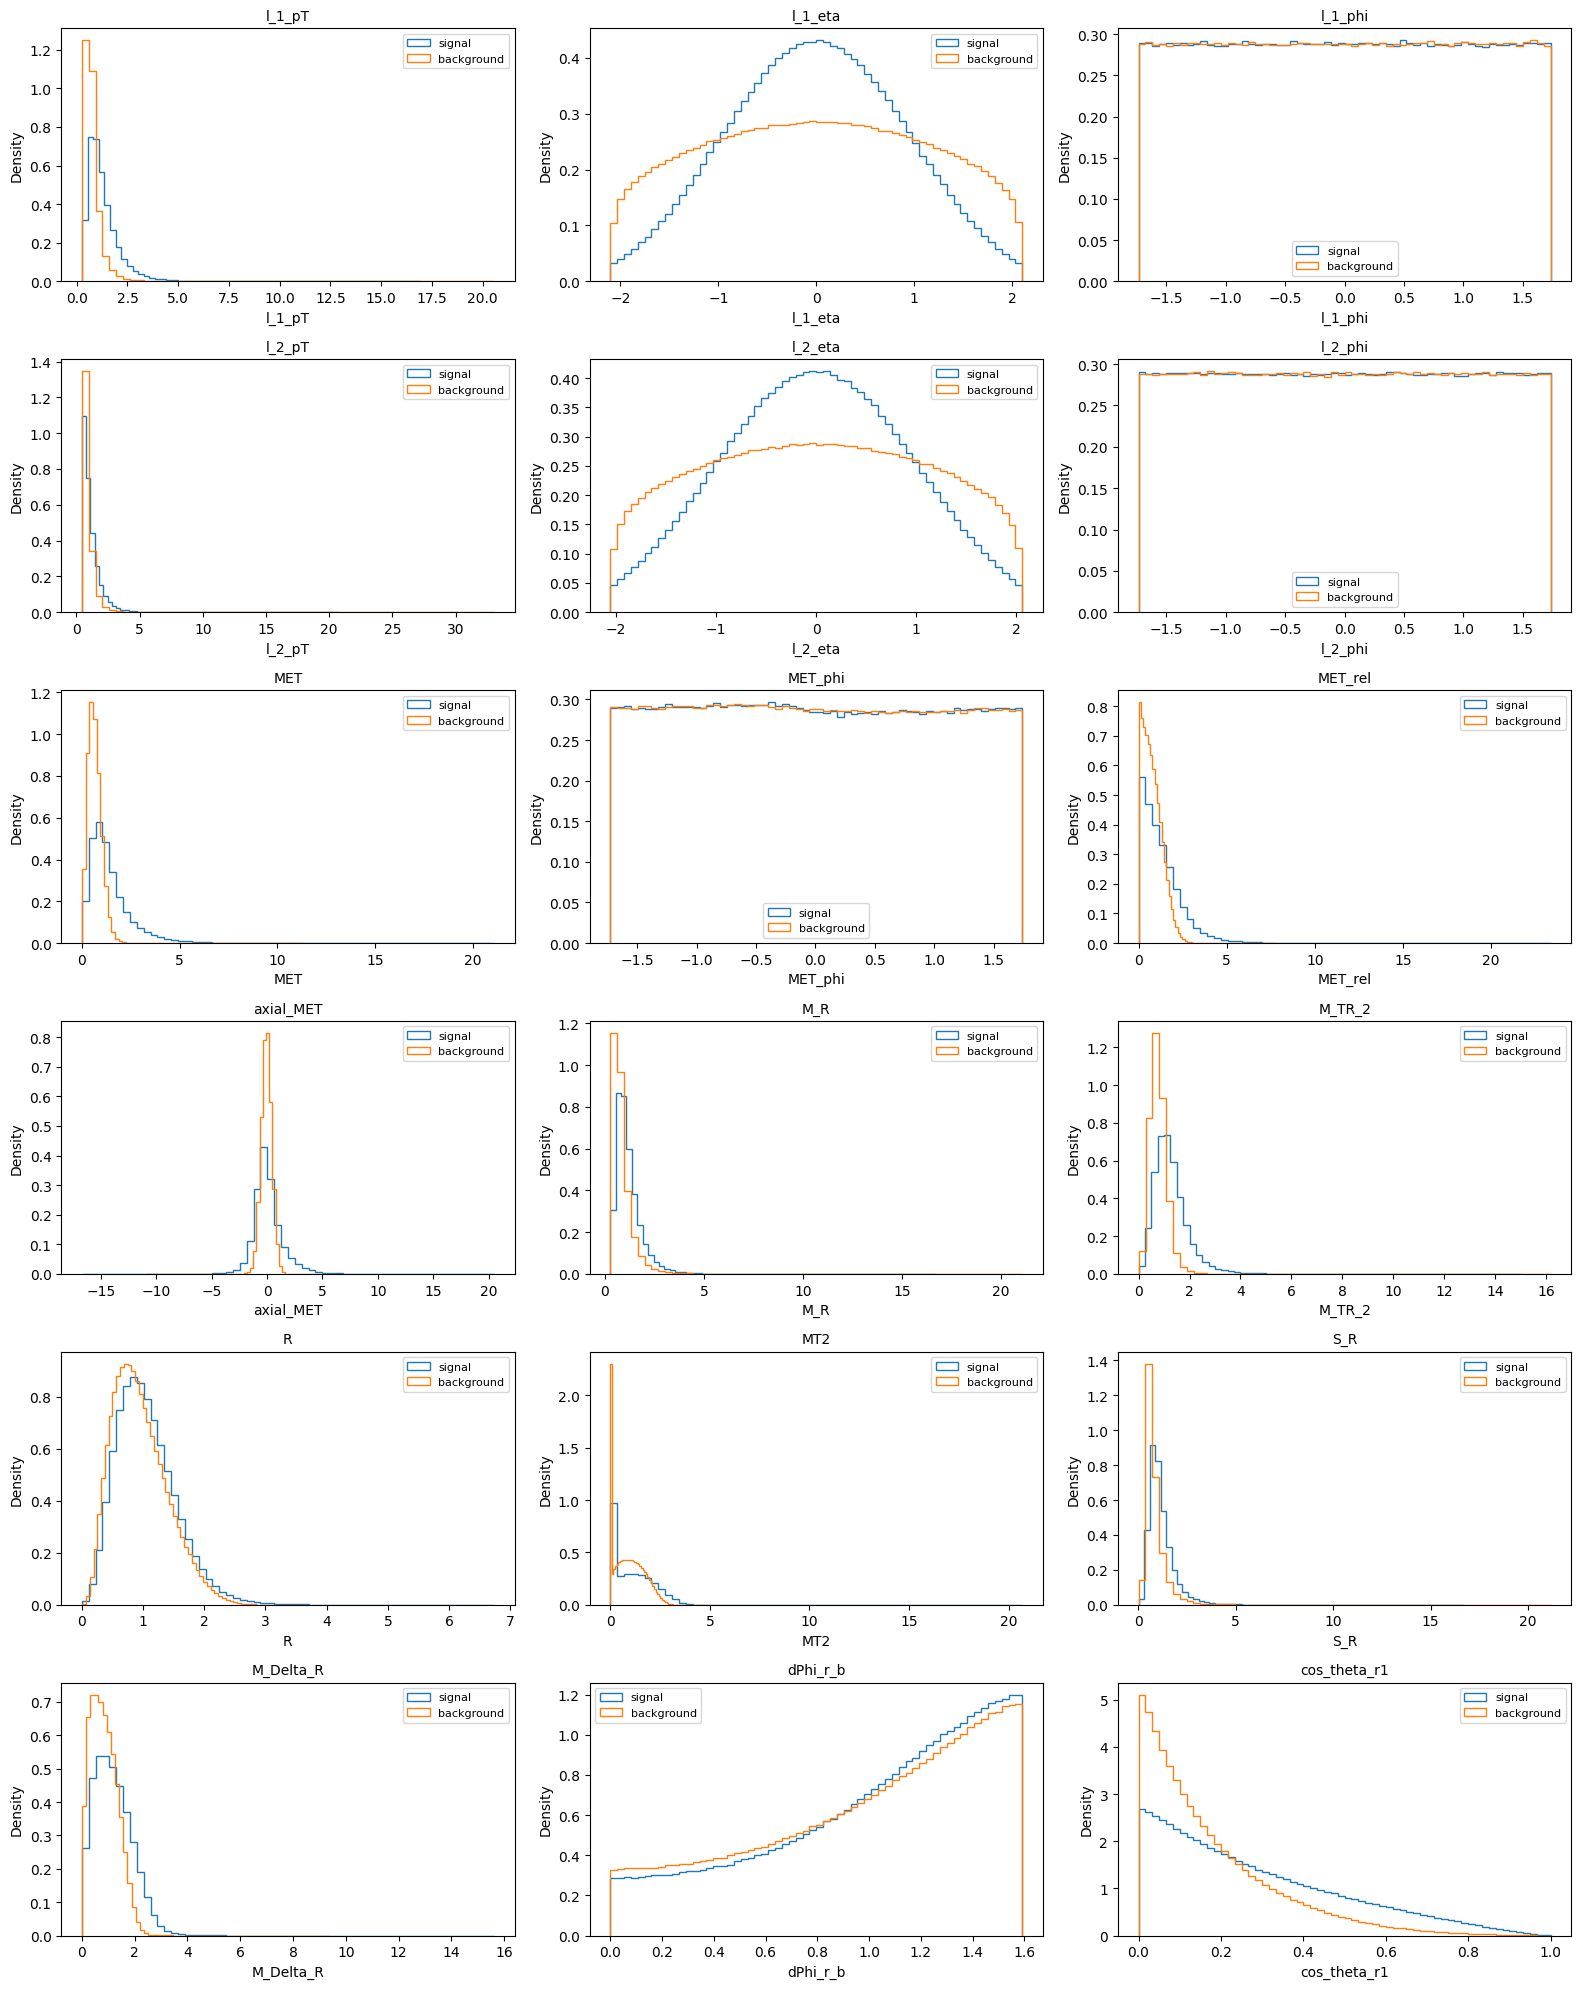

In [30]:
# Exercise 3: Reproduce a cleaner multi-panel figure for all observables.

plot_vars = VarNames[1:]
fig, axes = plt.subplots(6, 3, figsize=(16, 20))
axes = axes.flatten()

for ax, var in zip(axes, plot_vars):
    ax.hist(df_sig[var], bins=60, histtype="step", density=True, label="signal")
    ax.hist(df_bkg[var], bins=60, histtype="step", density=True, label="background")
    ax.set_title(var, fontsize=10)
    ax.set_xlabel(var)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

for i in range(len(plot_vars), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

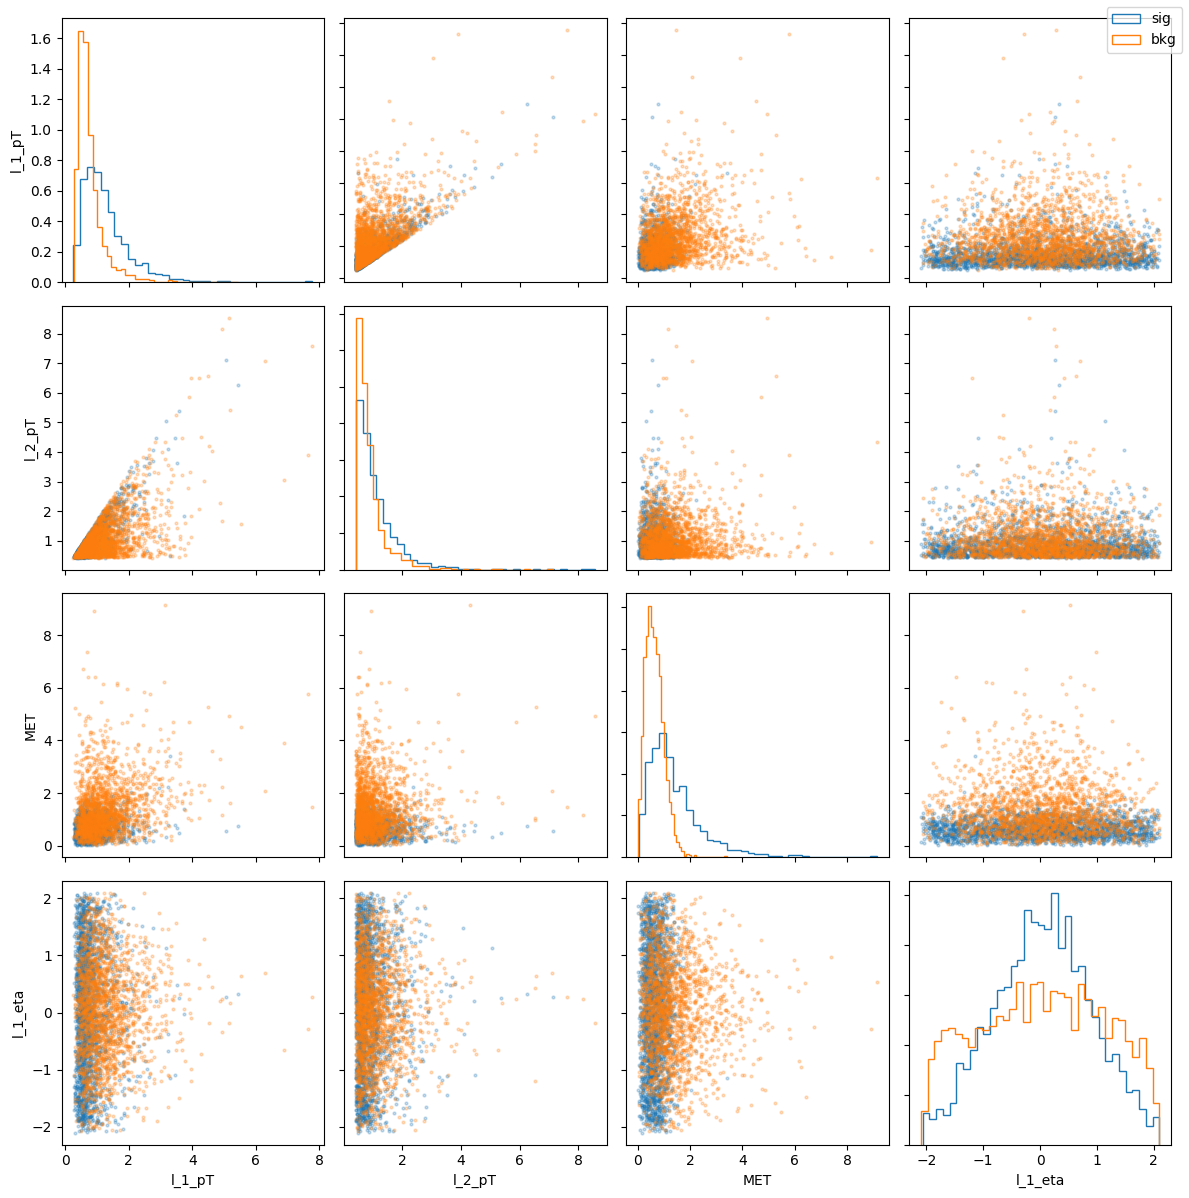

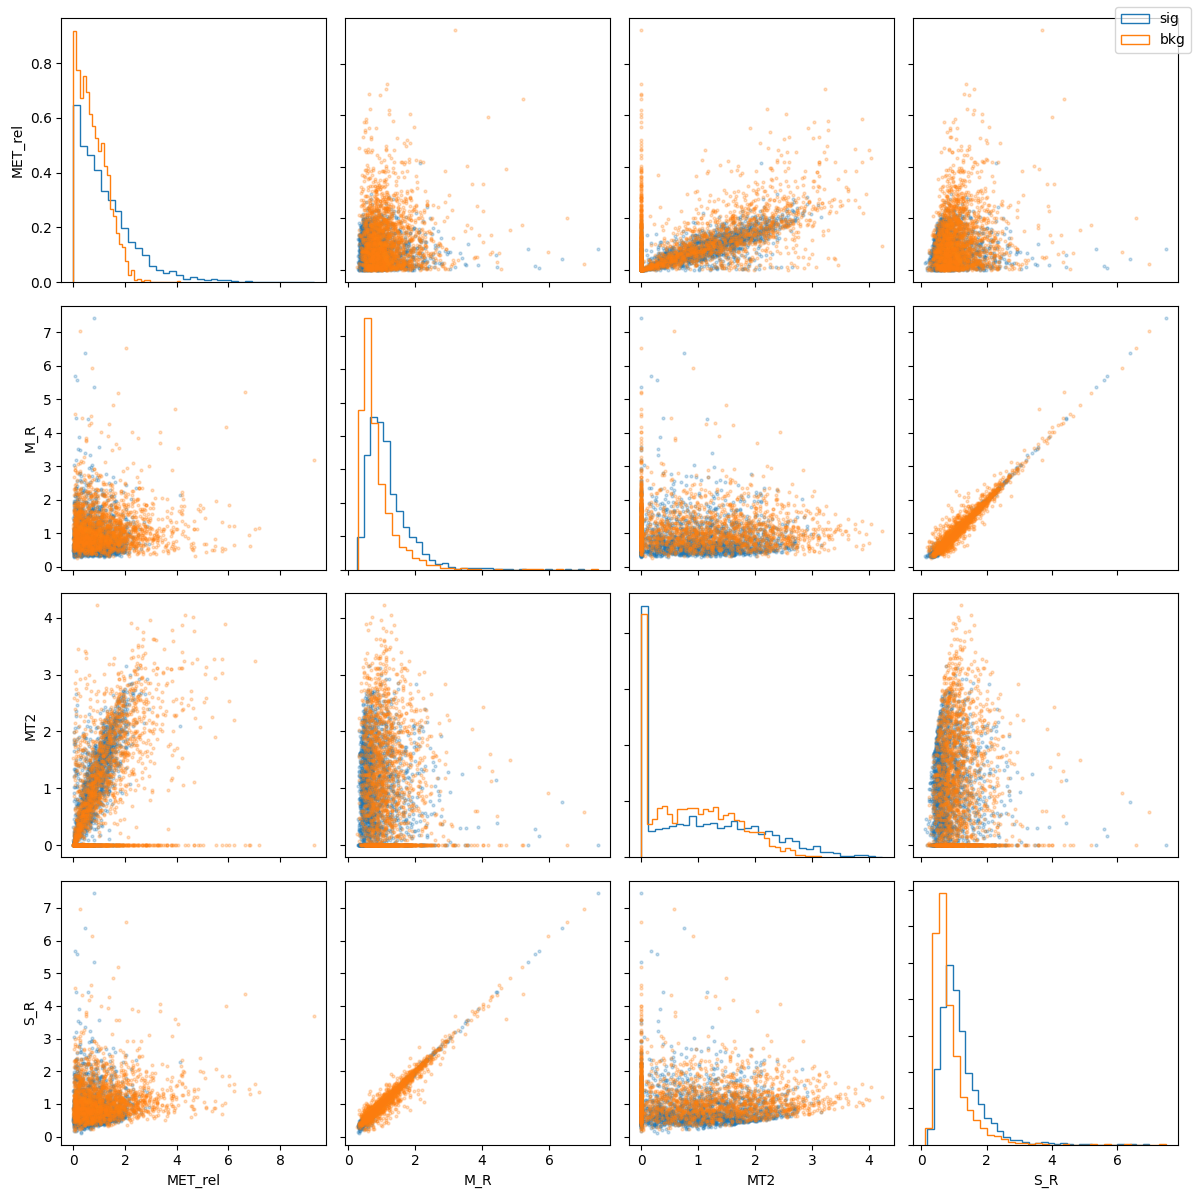

MET              0.5318
M_TR_2           0.4813
l_1_pT           0.4292
MET_rel          0.3043
M_Delta_R        0.2848
cos_theta_r1     0.2797
M_R              0.2766
S_R              0.2674
l_2_pT           0.1992
R                0.1127
axial_MET        0.0833
MT2              0.0798
dPhi_r_b         0.0328
l_1_phi          0.0005
l_2_eta          0.0004
l_1_eta          0.0003
MET_phi          0.0001
l_2_phi          0.0001
Top variables above are best at separating signal vs background


In [37]:
# Exercise 4.1 Part a
# This function manually creates pair plots (since we are not allowed to use seaborn)
# Idea: diagonal = histogram, off-diagonal = scatter plots

def pair_plot_manual(data_sig, data_bkg, variables, sample_size=3000, bins=40):
    # Take a smaller random sample so plotting is faster
    sig_sample = data_sig[variables].sample(min(sample_size, len(data_sig)), random_state=42)
    bkg_sample = data_bkg[variables].sample(min(sample_size, len(data_bkg)), random_state=42)

    n = len(variables)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            if i == j:
                # On diagonal → compare distributions using histograms
                ax.hist(sig_sample[variables[i]], bins=bins, histtype="step", density=True, label="sig")
                ax.hist(bkg_sample[variables[i]], bins=bins, histtype="step", density=True, label="bkg")
            else:
                # Off diagonal → scatter plot to see correlation between variables
                ax.scatter(bkg_sample[variables[j]], bkg_sample[variables[i]], s=4, alpha=0.25, label="bkg")
                ax.scatter(sig_sample[variables[j]], sig_sample[variables[i]], s=4, alpha=0.25, label="sig")

            # Only show labels on outer plots to keep it clean
            if i == n - 1:
                ax.set_xlabel(variables[j])
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(variables[i])
            else:
                ax.set_yticklabels([])

    # Add legend once
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right")

    plt.tight_layout()
    plt.show()

# Using only raw (low-level) variables from detector measurements
low_vars = ["l_1_pT", "l_2_pT", "MET", "l_1_eta"]

pair_plot_manual(df_sig, df_bkg, low_vars, sample_size=2000, bins=35)

# Using derived (high-level) physics features
high_vars = ["MET_rel", "M_R", "MT2", "S_R"]

pair_plot_manual(df_sig, df_bkg, high_vars, sample_size=2000, bins=35)


# Exercise 4.1 Part b
# This is a faster version of the pair plot
# Improvements:
# 1. Smaller sample size
# 2. Convert dataframe to numpy once (faster access inside loops)

def fast_pair_plot(data_sig, data_bkg, variables, sample_size=1200, bins=30):
    sig_sample = data_sig[variables].sample(min(sample_size, len(data_sig)), random_state=42).to_numpy()
    bkg_sample = data_bkg[variables].sample(min(sample_size, len(data_bkg)), random_state=42).to_numpy()

    n = len(variables)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            if i == j:
                # Histogram comparison
                ax.hist(sig_sample[:, i], bins=bins, histtype="step", density=True)
                ax.hist(bkg_sample[:, i], bins=bins, histtype="step", density=True)
            else:
                # Scatter comparison
                ax.scatter(bkg_sample[:, j], bkg_sample[:, i], s=3, alpha=0.2)
                ax.scatter(sig_sample[:, j], sig_sample[:, i], s=3, alpha=0.2)

            if i == n - 1:
                ax.set_xlabel(variables[j])
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(variables[i])
            else:
                ax.set_yticklabels([])

    plt.tight_layout()
    plt.show()

# Explanation: converting to numpy avoids repeated pandas indexing, which speeds things up

# Exercise 4.1 Part c
# We compute a simple "separation score" to see which variables differ most
# between signal and background

def separation_score(sig, bkg, var):
    m1, m0 = sig[var].mean(), bkg[var].mean()
    s1, s0 = sig[var].std(), bkg[var].std()
    return abs(m1 - m0) / (s1 + s0 + 1e-12)

scores = []
for var in VarNames[1:]:
    scores.append((var, separation_score(df_sig, df_bkg, var)))

# Sort variables from best to worst
scores = sorted(scores, key=lambda x: x[1], reverse=True)

for var, score in scores:
    print(f"{var:15s}  {score:.4f}")

print("Top variables above are best at separating signal vs background")


### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [40]:
# Exercise 4.2

from IPython.display import HTML, display
import tabulate

# PART B

# Convert dataframe to numpy for faster computation
all_vars = VarNames[1:]

cov_all = np.cov(df[all_vars].to_numpy(), rowvar=False)
corr_all = np.corrcoef(df[all_vars].to_numpy(), rowvar=False)

cov_low = np.cov(df[RawNames].to_numpy(), rowvar=False)
corr_low = np.corrcoef(df[RawNames].to_numpy(), rowvar=False)

cov_high = np.cov(df[FeatureNames].to_numpy(), rowvar=False)
corr_high = np.corrcoef(df[FeatureNames].to_numpy(), rowvar=False)

print("Matrices computed")

# Part C

# Helper function to display nice tables
def show_table(matrix, headers, title):
    rounded = [[f"{val:.3f}" for val in row] for row in matrix]
    table = [[headers[i]] + rounded[i] for i in range(len(headers))]
    html = tabulate.tabulate(table, headers=[title] + headers, tablefmt="html")
    display(HTML(html))

show_table(corr_low, RawNames, "Low-level corr")
show_table(corr_high, FeatureNames, "High-level corr")

# Part D

# Function so we can reuse this later easily
def covariance_report(data, variables, name):
    arr = data[variables].to_numpy()
    cov = np.cov(arr, rowvar=False)
    corr = np.corrcoef(arr, rowvar=False)

    print(f"{name} covariance")
    show_table(cov, variables, name + " cov")

    print(f"{name} correlation")
    show_table(corr, variables, name + " corr")

    return cov, corr

# Run function
covariance_report(df, RawNames, "Low-level")
covariance_report(df, FeatureNames, "High-level")

Matrices computed


Low-level corr,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0,-0,0.685,-0,0,0.385,-0.001
l_1_eta,-0,1,0,-0.001,0.403,0,-0.001,-0.001
l_1_phi,-0,0,1,-0,0.001,-0.267,0.001,-0.184
l_2_pT,0.685,-0.001,-0,1,-0.001,0,0.14,-0.002
l_2_eta,-0,0.403,0.001,-0.001,1,-0,0,-0
l_2_phi,0,0,-0.267,0,-0,1,0,-0.034
MET,0.385,-0.001,0.001,0.14,0,0,1,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.034,-0.002,1


High-level corr,MT2,MET_rel,S_R,dPhi_r_b,M_Delta_R,M_R,R,M_TR_2,cos_theta_r1,axial_MET
MT2,1,0.536,-0.021,0.056,0.808,-0.068,0.574,0.378,0.263,-0.535
MET_rel,0.536,1,0.149,0.378,0.749,0.078,0.595,0.583,0.317,-0.141
S_R,-0.021,0.149,1,-0.013,0.248,0.981,-0.285,0.636,-0.084,-0.07
dPhi_r_b,0.056,0.378,-0.013,1,0.156,-0.106,0.424,0.228,0.106,-0.06
M_Delta_R,0.808,0.749,0.248,0.156,1,0.189,0.564,0.666,0.319,-0.375
M_R,-0.068,0.078,0.981,-0.106,0.189,1,-0.381,0.578,-0.115,0.024
R,0.574,0.595,-0.285,0.424,0.564,-0.381,1,0.38,0.627,-0.385
M_TR_2,0.378,0.583,0.636,0.228,0.666,0.578,0.38,1,0.451,-0.323
cos_theta_r1,0.263,0.317,-0.084,0.106,0.319,-0.115,0.627,0.451,1,-0.274
axial_MET,-0.535,-0.141,-0.07,-0.06,-0.375,0.024,-0.385,-0.323,-0.274,1


Low-level covariance


Low-level cov,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.472,-0,-0,0.308,-0,0,0.231,-0.001
l_1_eta,-0,1.006,0,-0,0.406,0,-0.001,-0.001
l_1_phi,-0,0,1.003,-0,0.001,-0.268,0.001,-0.184
l_2_pT,0.308,-0,-0,0.428,-0,0,0.08,-0.001
l_2_eta,-0,0.406,0.001,-0,1.006,-0,0,-0
l_2_phi,0,0,-0.268,0,-0,1.003,0,-0.034
MET,0.231,-0.001,0.001,0.08,0,0,0.762,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.001,-0,-0.034,-0.002,1.003


...

High-level covariance


High-level cov,MT2,MET_rel,S_R,dPhi_r_b,M_Delta_R,M_R,R,M_TR_2,cos_theta_r1,axial_MET
MT2,0.738,0.41,-0.011,0.021,0.433,-0.037,0.232,0.189,0.045,-0.46
MET_rel,0.41,0.792,0.082,0.147,0.416,0.044,0.25,0.303,0.056,-0.125
S_R,-0.011,0.082,0.385,-0.004,0.096,0.383,-0.083,0.23,-0.01,-0.043
dPhi_r_b,0.021,0.147,-0.004,0.19,0.042,-0.029,0.087,0.058,0.009,-0.026
M_Delta_R,0.433,0.416,0.096,0.042,0.389,0.074,0.166,0.242,0.039,-0.234
M_R,-0.037,0.044,0.383,-0.029,0.074,0.395,-0.113,0.212,-0.014,0.015
R,0.232,0.25,-0.083,0.087,0.166,-0.113,0.222,0.104,0.058,-0.182
M_TR_2,0.189,0.303,0.23,0.058,0.242,0.212,0.104,0.341,0.052,-0.189
cos_theta_r1,0.045,0.056,-0.01,0.009,0.039,-0.014,0.058,0.052,0.039,-0.054
axial_MET,-0.46,-0.125,-0.043,-0.026,-0.234,0.015,-0.182,-0.189,-0.054,1.003


High-level correlation


High-level corr,MT2,MET_rel,S_R,dPhi_r_b,M_Delta_R,M_R,R,M_TR_2,cos_theta_r1,axial_MET
MT2,1,0.536,-0.021,0.056,0.808,-0.068,0.574,0.378,0.263,-0.535
MET_rel,0.536,1,0.149,0.378,0.749,0.078,0.595,0.583,0.317,-0.141
S_R,-0.021,0.149,1,-0.013,0.248,0.981,-0.285,0.636,-0.084,-0.07
dPhi_r_b,0.056,0.378,-0.013,1,0.156,-0.106,0.424,0.228,0.106,-0.06
M_Delta_R,0.808,0.749,0.248,0.156,1,0.189,0.564,0.666,0.319,-0.375
M_R,-0.068,0.078,0.981,-0.106,0.189,1,-0.381,0.578,-0.115,0.024
R,0.574,0.595,-0.285,0.424,0.564,-0.381,1,0.38,0.627,-0.385
M_TR_2,0.378,0.583,0.636,0.228,0.666,0.578,0.38,1,0.451,-0.323
cos_theta_r1,0.263,0.317,-0.084,0.106,0.319,-0.115,0.627,0.451,1,-0.274
axial_MET,-0.535,-0.141,-0.07,-0.06,-0.375,0.024,-0.385,-0.323,-0.274,1


(array([[ 0.73830903,  0.4100222 , -0.01116591,  0.02117007,  0.43332669,
         -0.03662338,  0.23220317,  0.1894982 ,  0.04452951, -0.46031246],
        [ 0.4100222 ,  0.79239696,  0.0824171 ,  0.14659656,  0.41567466,
          0.04370602,  0.24951055,  0.30334551,  0.05560498, -0.12527291],
        [-0.01116591,  0.0824171 ,  0.38528896, -0.00363167,  0.0961442 ,
          0.38305852, -0.08342831,  0.23044835, -0.01022307, -0.04341721],
        [ 0.02117007,  0.14659656, -0.00363167,  0.19017871,  0.04238627,
         -0.02913224,  0.08712903,  0.05813285,  0.00912875, -0.02620925],
        [ 0.43332669,  0.41567466,  0.0961442 ,  0.04238627,  0.38908552,
          0.07427758,  0.16564653,  0.24248702,  0.03920007, -0.23410285],
        [-0.03662338,  0.04370602,  0.38305852, -0.02913224,  0.07427758,
          0.39544556, -0.11292219,  0.21215446, -0.01419408,  0.01510465],
        [ 0.23220317,  0.24951055, -0.08342831,  0.08712903,  0.16564653,
         -0.11292219,  0.2216909

Hint: Example code for embedding a `tabulate` table into a notebook:

In [15]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

l_1_pT ('x > xc', np.float64(0.9689015144079773))
l_1_eta ('|x-mu| < xc', np.float64(1.531140810281188))
l_1_phi ('|x-mu| > xc', np.float64(-1.7347885370254517))
l_2_pT ('|x-mu| < xc', np.float64(16.15861323266173))
l_2_eta ('|x-mu| < xc', np.float64(1.6250495742912867))
l_2_phi ('|x-mu| > xc', np.float64(-1.7342021465301511))
MET ('x > xc', np.float64(1.5883465340681577))
MET_phi ('x < xc', np.float64(1.7406890392303467))
MET_rel ('|x-mu| > xc', np.float64(1.2927177715125349))
axial_MET ('|x-mu| > xc', np.float64(1.230248638133908))
M_R ('x > xc', np.float64(0.685566558310734))
M_TR_2 ('x > xc', np.float64(1.3008023778745323))
R ('|x-mu| < xc', np.float64(5.75057815384803))
MT2 ('|x-mu| > xc', np.float64(0.0))
S_R ('x > xc', np.float64(0.6642736201572359))
M_Delta_R ('x > xc', np.float64(0.08289130949345067))
dPhi_r_b ('x > xc', np.float64(3.211848706996534e-07))
cos_theta_r1 ('x > xc', np.float64(4.172130019242104e-08))


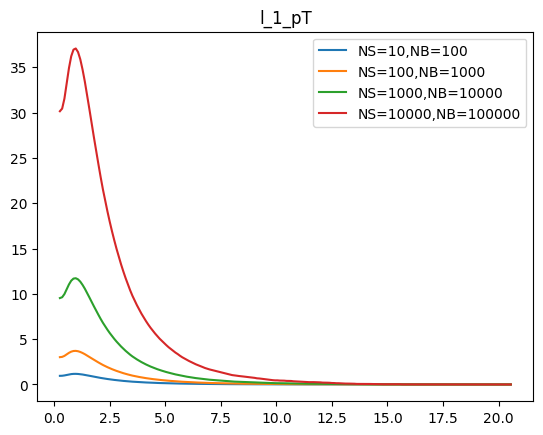

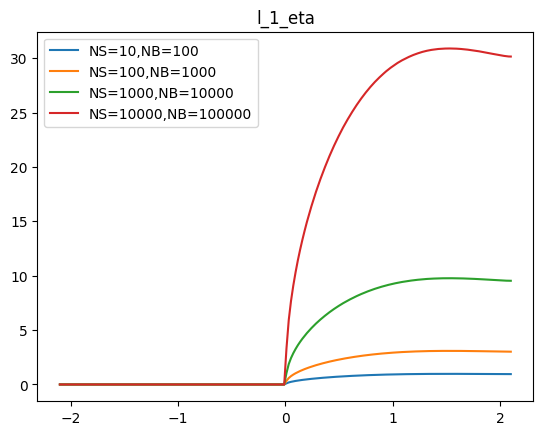

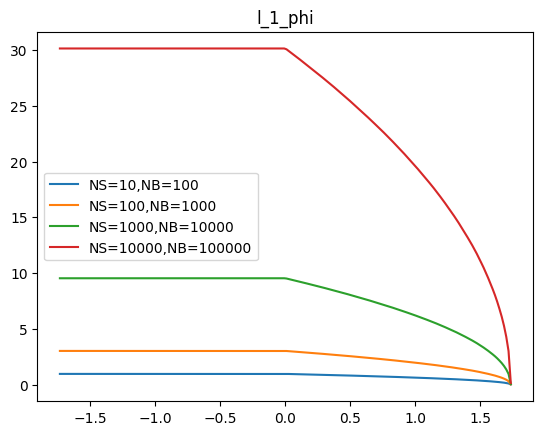

In [41]:
# Exercise 5

# Exercise 5.1

# Significance formula

def significance_from_rates(tpr, fpr, NS, NB):
    Ns = tpr * NS
    Nb = fpr * NB
    return Ns / np.sqrt(Ns + Nb + 1e-12)

# Apply rule helper

def apply_rule(values, rule, xc, mu):
    if rule == "x > xc": return values > xc
    if rule == "x < xc": return values < xc
    if rule == "|x-mu| > xc": return np.abs(values - mu) > xc
    if rule == "|x-mu| < xc": return np.abs(values - mu) < xc

best_rules = {}

for var in VarNames[1:]:
    xs = np.linspace(df[var].min(), df[var].max(), 200)
    mu = np.mean(df[var])
    sig_vals = df_sig[var].to_numpy()
    bkg_vals = df_bkg[var].to_numpy()

    best_score = -1
    best = None

    for xc in xs:
        rules = {
            "x > xc": (sig_vals > xc, bkg_vals > xc),
            "x < xc": (sig_vals < xc, bkg_vals < xc),
            "|x-mu| > xc": (np.abs(sig_vals - mu) > xc, np.abs(bkg_vals - mu) > xc),
            "|x-mu| < xc": (np.abs(sig_vals - mu) < xc, np.abs(bkg_vals - mu) < xc),
        }

        for rule, (ms, mb) in rules.items():
            score = significance_from_rates(ms.mean(), mb.mean(), 1000, 10000)
            if score > best_score:
                best_score = score
                best = (rule, xc)

    best_rules[var] = best
    print(var, best)

# Exercise 5.2 & 5.3 

scenarios = [(10,100),(100,1000),(1000,10000),(10000,100000)]

for var in VarNames[1:4]:
    rule, _ = best_rules[var]
    xs = np.linspace(df[var].min(), df[var].max(), 200)
    mu = np.mean(df[var])

    sig_vals = df_sig[var].to_numpy()
    bkg_vals = df_bkg[var].to_numpy()

    plt.figure()

    for NS, NB in scenarios:
        scores = []
        for xc in xs:
            ms = apply_rule(sig_vals, rule, xc, mu)
            mb = apply_rule(bkg_vals, rule, xc, mu)
            scores.append(significance_from_rates(ms.mean(), mb.mean(), NS, NB))
        plt.plot(xs, scores, label=f"NS={NS},NB={NB}")

    plt.title(var)
    plt.legend()
    plt.show()

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [43]:
# Exercise 6: Cut Flow
# This combines 6.1, 6.2, and 6.3 in one cell

# Exercise 6.1
# Choose at least 3 observables based on Exercise 5 results
# Here I am taking the first 3 from best_rules (can be adjusted if needed)

top_vars = list(best_rules.keys())[:3]

# Loop over each scenario (same ones from Exercise 5.3)
for NS, NB in scenarios:
    print(f"\nScenario NS={NS}, NB={NB}")

    # Start with full datasets
    sig_current = df_sig.copy()
    bkg_current = df_bkg.copy()

    # Exercise 6.2
    # Apply cuts one by one and compute cut-flow values
    for step, var in enumerate(top_vars, start=1):

        # Get rule and threshold from Exercise 5
        rule, xc = best_rules[var]

        # Mean is needed for |x - mu| rules
        mu = np.mean(df[var])

        # Apply cut to current data
        sig_mask = apply_rule(sig_current[var].to_numpy(), rule, xc, mu)
        bkg_mask = apply_rule(bkg_current[var].to_numpy(), rule, xc, mu)

        # Keep only events that pass the cut
        sig_current = sig_current[sig_mask]
        bkg_current = bkg_current[bkg_mask]

        # Compute efficiencies
        eps_s = len(sig_current) / len(df_sig)
        eps_b = len(bkg_current) / len(df_bkg)

        # Expected surviving events
        Ns_p = eps_s * NS
        Nb_p = eps_b * NB

        # Compute significance
        sigma = Ns_p / np.sqrt(Ns_p + Nb_p + 1e-12)

        # Print cut-flow step
        print(f"\nStep {step}: {var}")
        print(f"   Rule used: {rule}")
        print(f"   xc = {xc:.4f}")
        print(f"   eps_s = {eps_s:.4f}, eps_b = {eps_b:.4f}")
        print(f"   Ns' = {Ns_p:.2f}, Nb' = {Nb_p:.2f}")
        print(f"   sigma = {sigma:.4f}")

    # Exercise 6.3
    # Comment on correlation and order of cuts
    print("\n[6.3 Observation]")
    print("The result depends on the order of cuts because some variables are correlated.")
    print("Applying one cut can remove information useful for the next cut.")
    print("Changing the order may give a different (sometimes worse or better) significance.")


Scenario NS=10, NB=100

Step 1: l_1_pT
   Rule used: x > xc
   xc = 0.9689
   eps_s = 0.5819, eps_b = 0.1881
   Ns' = 5.82, Nb' = 18.81
   sigma = 1.1724

Step 2: l_1_eta
   Rule used: |x-mu| < xc
   xc = 1.5311
   eps_s = 0.5478, eps_b = 0.1532
   Ns' = 5.48, Nb' = 15.32
   sigma = 1.2010

Step 3: l_1_phi
   Rule used: |x-mu| > xc
   xc = -1.7348
   eps_s = 0.5478, eps_b = 0.1532
   Ns' = 5.48, Nb' = 15.32
   sigma = 1.2010

[6.3 Observation]
The result depends on the order of cuts because some variables are correlated.
Applying one cut can remove information useful for the next cut.
Changing the order may give a different (sometimes worse or better) significance.

Scenario NS=100, NB=1000

Step 1: l_1_pT
   Rule used: x > xc
   xc = 0.9689
   eps_s = 0.5819, eps_b = 0.1881
   Ns' = 58.19, Nb' = 188.10
   sigma = 3.7076

Step 2: l_1_eta
   Rule used: |x-mu| < xc
   xc = 1.5311
   eps_s = 0.5478, eps_b = 0.1532
   Ns' = 54.78, Nb' = 153.24
   sigma = 3.7979

Step 3: l_1_phi
   Rule us

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



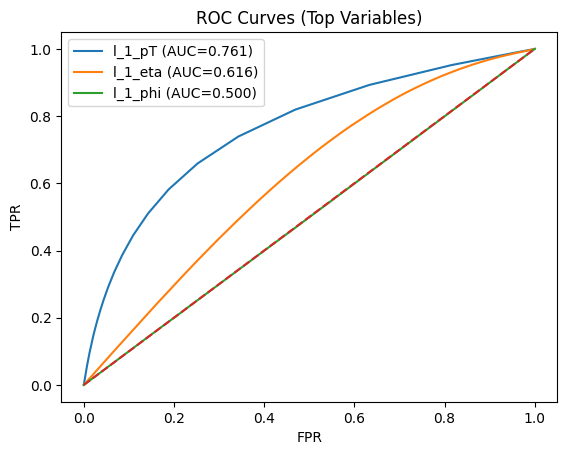

Reusable function created.

After 0 cut(s):


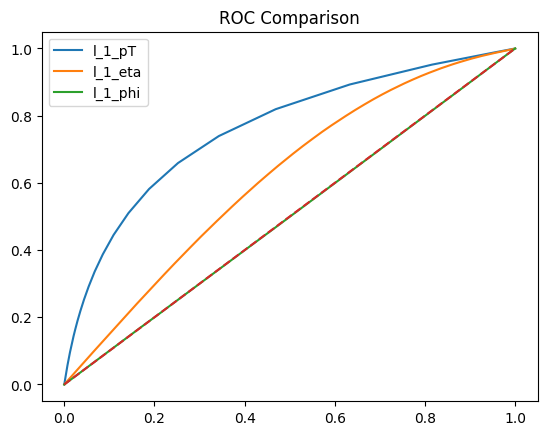


After 1 cut(s):


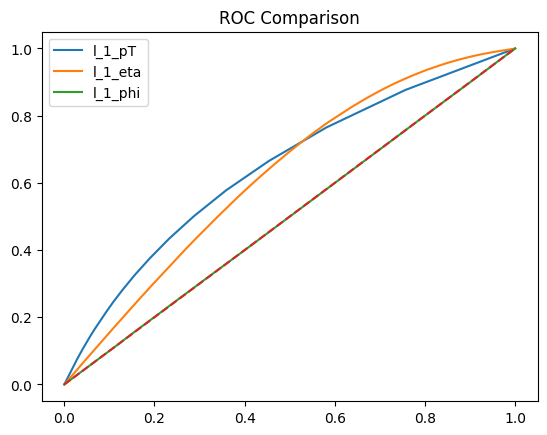


After 2 cut(s):


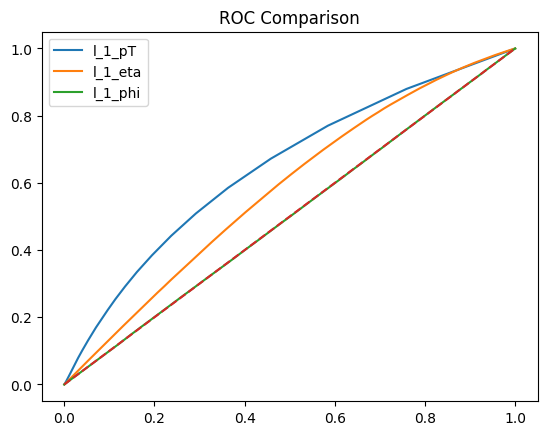


After 3 cut(s):


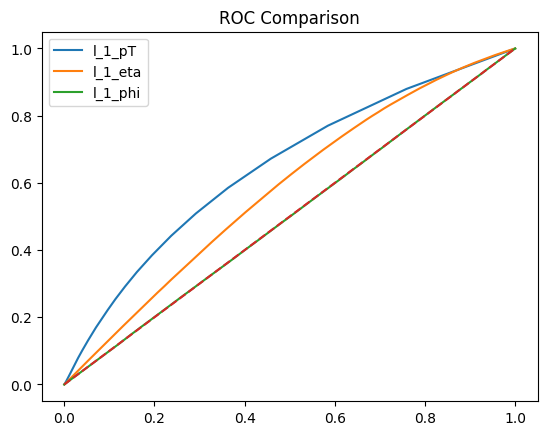

ROC with original order:


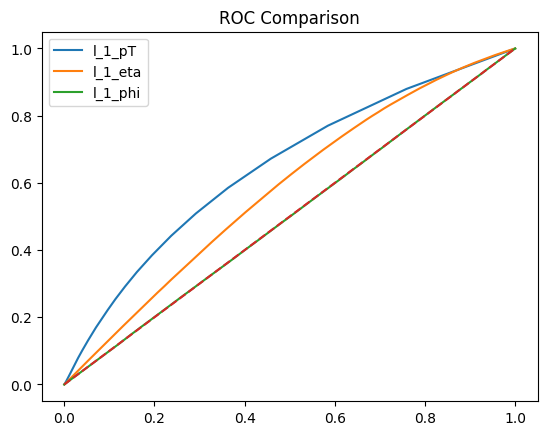

ROC with reversed order:


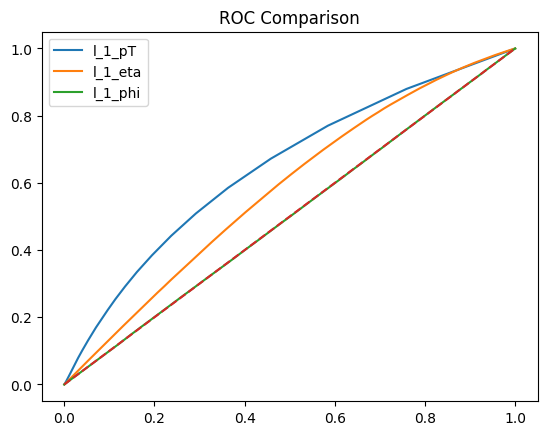


[Observation]
ROC curves show how well each variable separates signal and background.
Combining cuts usually improves performance, but order can change results due to correlation.


In [46]:
# Exercise 7: ROC Curves

# Helper function to compute ROC curve
def roc_curve(sig_vals, bkg_vals, rule, xs, mu):
    tpr, fpr = [], []

    for xc in xs:
        ms = apply_rule(sig_vals, rule, xc, mu)
        mb = apply_rule(bkg_vals, rule, xc, mu)

        tpr.append(ms.mean())  # signal efficiency
        fpr.append(mb.mean())  # background efficiency

    return np.array(fpr), np.array(tpr)

# Exercise 7.1
# Plot ROC curves for top 3 variables

top_vars = list(best_rules.keys())[:3]

plt.figure()

for var in top_vars:
    rule, _ = best_rules[var]

    xs = np.linspace(df[var].min(), df[var].max(), 200)
    mu = np.mean(df[var])

    sig_vals = df_sig[var].to_numpy()
    bkg_vals = df_bkg[var].to_numpy()

    fpr, tpr = roc_curve(sig_vals, bkg_vals, rule, xs, mu)

    # Compute AUC using trapezoidal rule
    order = np.argsort(fpr)
    auc = np.trapezoid(tpr[order], fpr[order])

    plt.plot(fpr, tpr, label=f"{var} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'--')  # random classifier line
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves (Top Variables)")
plt.legend()
plt.show()

# Exercise 7.2
# Function to reuse ROC plotting

def plot_roc_vars(data_sig, data_bkg, variables):
    plt.figure()

    for var in variables:
        rule, _ = best_rules[var]

        xs = np.linspace(df[var].min(), df[var].max(), 200)
        mu = np.mean(df[var])

        fpr, tpr = roc_curve(
            data_sig[var].to_numpy(),
            data_bkg[var].to_numpy(),
            rule, xs, mu
        )

        plt.plot(fpr, tpr, label=var)

    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title("ROC Comparison")
    plt.show()

print("Reusable function created.")

# Exercise 7.3
# ROC after each selection (cut flow)

sig_now = df_sig.copy()
bkg_now = df_bkg.copy()

for step in range(len(top_vars) + 1):
    print(f"\nAfter {step} cut(s):")
    plot_roc_vars(sig_now, bkg_now, top_vars)

    # Apply next cut
    if step < len(top_vars):
        var = top_vars[step]
        rule, xc = best_rules[var]
        mu = np.mean(df[var])

        sig_now = sig_now[apply_rule(sig_now[var].to_numpy(), rule, xc, mu)]
        bkg_now = bkg_now[apply_rule(bkg_now[var].to_numpy(), rule, xc, mu)]

# Exercise 7.4
# Effect of changing order of cuts

# Original order
sig_now = df_sig.copy()
bkg_now = df_bkg.copy()

for var in top_vars:
    rule, xc = best_rules[var]
    mu = np.mean(df[var])

    sig_now = sig_now[apply_rule(sig_now[var].to_numpy(), rule, xc, mu)]
    bkg_now = bkg_now[apply_rule(bkg_now[var].to_numpy(), rule, xc, mu)]

print("ROC with original order:")
plot_roc_vars(sig_now, bkg_now, top_vars)


# Reversed order
sig_now = df_sig.copy()
bkg_now = df_bkg.copy()

for var in reversed(top_vars):
    rule, xc = best_rules[var]
    mu = np.mean(df[var])

    sig_now = sig_now[apply_rule(sig_now[var].to_numpy(), rule, xc, mu)]
    bkg_now = bkg_now[apply_rule(bkg_now[var].to_numpy(), rule, xc, mu)]

print("ROC with reversed order:")
plot_roc_vars(sig_now, bkg_now, top_vars)

# Final observation
print("\n[Observation]")
print("ROC curves show how well each variable separates signal and background.")
print("Combining cuts usually improves performance, but order can change results due to correlation.")

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.2

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.3

Draw the ROC curve for $F_n$. 

### Exercise 8.4

What is the maximal significance you can obtain in the scenarios in exercise 5? 

8.1 done: computed S_B and S_W
S_B shape: (18, 18)
S_W shape: (18, 18)


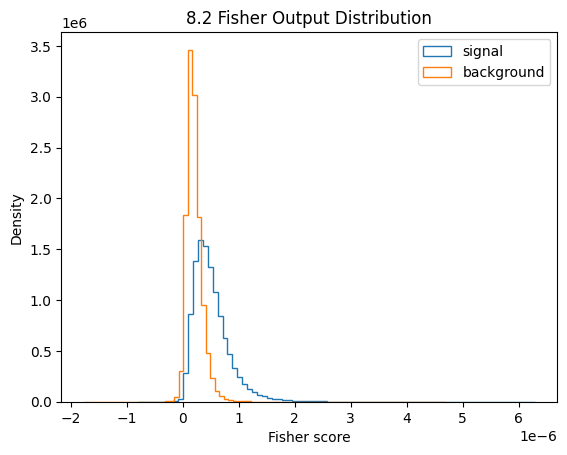

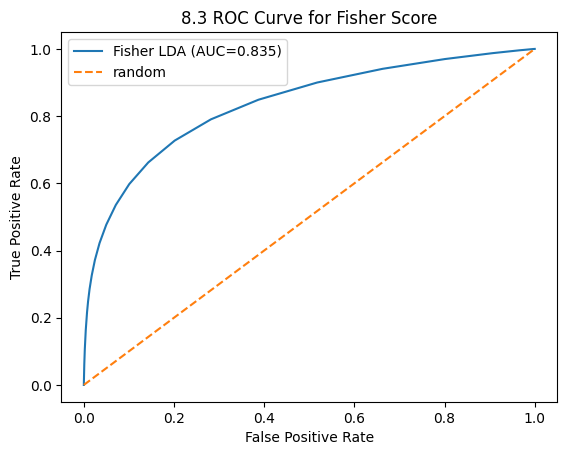

Scenario NS=10, NB=100
   Best threshold = 0.0000
   Max significance = 1.5273
---------------------------------------------
Scenario NS=100, NB=1000
   Best threshold = 0.0000
   Max significance = 4.8298
---------------------------------------------
Scenario NS=1000, NB=10000
   Best threshold = 0.0000
   Max significance = 15.2733
---------------------------------------------
Scenario NS=10000, NB=100000
   Best threshold = 0.0000
   Max significance = 48.2984
---------------------------------------------

[Observation]
The Fisher discriminant combines all variables into one score.
This usually separates signal and background better than using only one variable at a time.


In [48]:
# Exercise 8: Linear Discriminant

# Exercise 8.1
# Compute between-class scatter matrix S_B
# and within-class scatter matrix S_W

# Use all observables except the label column
X_sig = df_sig[VarNames[1:]].to_numpy()
X_bkg = df_bkg[VarNames[1:]].to_numpy()

# Mean vector for signal and background
m_sig = X_sig.mean(axis=0).reshape(-1, 1)
m_bkg = X_bkg.mean(axis=0).reshape(-1, 1)

# Between-class scatter
# This measures how far apart the two class means are
S_B = (m_sig - m_bkg) @ (m_sig - m_bkg).T

# Within-class scatter
# This measures how spread out the points are inside each class
S_W = (X_sig - m_sig.ravel()).T @ (X_sig - m_sig.ravel()) + \
      (X_bkg - m_bkg.ravel()).T @ (X_bkg - m_bkg.ravel())

print("8.1 done: computed S_B and S_W")
print("S_B shape:", S_B.shape)
print("S_W shape:", S_W.shape)

# Exercise 8.2
# Compute Fisher linear discriminant weights
# and compare the output distributions

# Use pseudo-inverse in case S_W is not perfectly invertible
w = np.linalg.pinv(S_W) @ (m_sig - m_bkg)

# Project both classes onto the Fisher direction
F_sig = (X_sig @ w).ravel()
F_bkg = (X_bkg @ w).ravel()

plt.figure()
plt.hist(F_sig, bins=80, histtype="step", density=True, label="signal")
plt.hist(F_bkg, bins=80, histtype="step", density=True, label="background")
plt.xlabel("Fisher score")
plt.ylabel("Density")
plt.title("8.2 Fisher Output Distribution")
plt.legend()
plt.show()

# Exercise 8.3
# Draw ROC curve for Fisher score

thresholds = np.linspace(min(F_sig.min(), F_bkg.min()),
                         max(F_sig.max(), F_bkg.max()), 200)

tpr = []
fpr = []

for t in thresholds:
    # If score is above threshold, classify as signal
    tpr.append((F_sig > t).mean())
    fpr.append((F_bkg > t).mean())

tpr = np.array(tpr)
fpr = np.array(fpr)

# Compute AUC safely
order = np.argsort(fpr)
auc = np.trapezoid(tpr[order], fpr[order])

plt.figure()
plt.plot(fpr, tpr, label=f"Fisher LDA (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("8.3 ROC Curve for Fisher Score")
plt.legend()
plt.show()

# Exercise 8.4
# Find the maximum significance for each scenario

for NS, NB in scenarios:
    best_sigma = -1
    best_t = None

    for t in thresholds:
        eps_s = (F_sig > t).mean()
        eps_b = (F_bkg > t).mean()

        Ns_p = eps_s * NS
        Nb_p = eps_b * NB

        sigma = Ns_p / np.sqrt(Ns_p + Nb_p + 1e-12)

        if sigma > best_sigma:
            best_sigma = sigma
            best_t = t

    print(f"Scenario NS={NS}, NB={NB}")
    print(f"   Best threshold = {best_t:.4f}")
    print(f"   Max significance = {best_sigma:.4f}")
    print("-" * 45)

# Final observation
print("\n[Observation]")
print("The Fisher discriminant combines all variables into one score.")
print("This usually separates signal and background better than using only one variable at a time.")